In [ ]:
import sys

import os
import os.path as op
import xarray as xr

import matplotlib.pyplot as plt
from cartopy import crs as ccrs
from bluemath.plotting.common import load_coast
import numpy as np

import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)


import numpy as np
import pandas as pd


import datetime
from datetime import timedelta


### CoDEC

In [36]:
longs = xr.open_dataset("https://geoocean.sci.unican.es/thredds/dodsC/faggregatedCODEC.nc").station_x_coordinate.values
longs

array([ 24.089,  24.089,  26.902, ..., 139.146,  37.749,  37.954],
      shape=(43119,))

In [34]:
lats = xr.open_dataset("https://geoocean.sci.unican.es/thredds/dodsC/faggregatedCODEC.nc").station_y_coordinate.values
lats

array([ 34.827,  34.871,  35.369, ...,  34.204, -46.978, -46.626],
      shape=(43119,))

In [41]:
stations = xr.open_dataset("https://geoocean.sci.unican.es/thredds/dodsC/faggregatedCODEC.nc").stations.values
stations

array([     0,      1,      2, ..., -21805, -21804, -21803],
      shape=(43119,), dtype=int16)

In [37]:
# Location coordinates

Lon = -8.76 
Lat = 41.17

In [38]:
# Closest values
closest_lon = longs[np.abs(longs - Lon).argmin()]
closest_lat = lats[np.abs(lats - Lat).argmin()]

print(f"Longitud más cercana: {closest_lon}")
print(f"Latitud más cercana:  {closest_lat}")

Longitud más cercana: -8.76
Latitud más cercana:  41.169000000000004


In [44]:
# look for an exact match (if it exists)
mask = (np.isclose(longs, closest_lon, atol=1e-8)) & (np.isclose(lats, closest_lat, atol=1e-8))
idxs = np.where(mask)[0]

if idxs.size > 0:
    # if there are exact matches (possibly multiple), return all of them
    matched_stations = stations[idxs]
    print("Matching station(s):", matched_stations, "indices:", idxs)
else:
    # if there is no exact match, find the station with the smallest Euclidean distance
    dist = np.sqrt((longs - closest_lon)**2 + (lats - closest_lat)**2)
    idx = np.argmin(dist)
    matched_station = stations[idx]
    print("No exact match found. Closest station:", matched_station, "index:", idx,
          "coords:", longs[idx], lats[idx], "distance:", dist[idx])


No exact match found. Closest station: -26096 index: 39359 coords: -8.708 41.184 distance: 0.05412023651093704


In [45]:
# 4-5 mins

ds = (
    xr.open_dataset("https://geoocean.sci.unican.es/thredds/dodsC/faggregatedCODEC.nc")
    .sel(stations=matched_station)
    .chunk({"time": 365 * 24})
    .load()
)
ds

<xarray.Dataset> Size: 8MB
Dimensions:               (time: 350640)
Coordinates:
    station_x_coordinate  float64 8B -8.708
    station_y_coordinate  float64 8B 41.18
    stations              int16 2B -26096
  * time                  (time) datetime64[ns] 3MB 1979-01-01 ... 2018-12-31...
Data variables:
    surge                 (time) float64 3MB 0.808 0.072 ... -0.123 -0.221
    waterlevel            (time) float64 3MB -0.026 0.049 0.023 ... 0.807 0.755
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_surge
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         Fast Aggregated CODEC
    ...                            ...
    time_coverage_start:           2018-11-01 00:00:00
    time_coverage_end:             2018-11-30 23:00:00
    experiment:                    reanalysis
    date_modified:                 2021-05-06 19:47:58.279267 UTC
    contact:                       Please contact Copernicus User Support on ...
    history:                       Created on 2024-12-08

In [46]:
ds.to_netcdf('ds_Oporto_codec.nc')

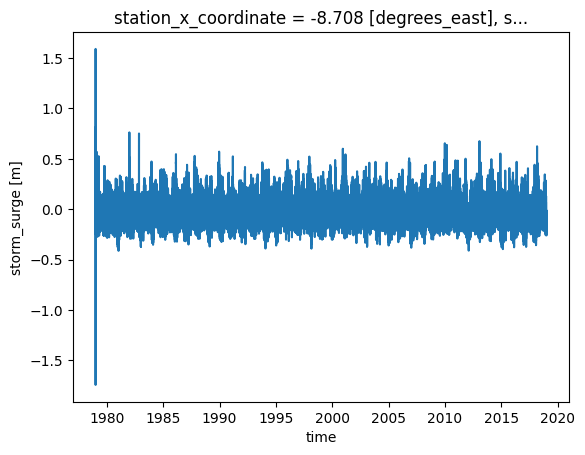

In [47]:
ds.surge.plot()

#### Total water level (astronomical tide + storm surge)

In [50]:
ds_codec = ds
ds_codec

<xarray.Dataset> Size: 8MB
Dimensions:               (time: 350640)
Coordinates:
    station_x_coordinate  float64 8B -8.708
    station_y_coordinate  float64 8B 41.18
    stations              int16 2B -26096
  * time                  (time) datetime64[ns] 3MB 1979-01-01 ... 2018-12-31...
Data variables:
    surge                 (time) float64 3MB 0.808 0.072 ... -0.123 -0.221
    waterlevel            (time) float64 3MB -0.026 0.049 0.023 ... 0.807 0.755
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_surge
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         Fast Aggregated CODEC
    ...                            ...
    time_coverage_start:           2018-11-01 00:00:00
    time_coverage_end:             2018-11-30 23:00:00
    experiment:                    reanalysis
    date_modified:                 2021-05-06 19:47:58.279267 UTC
    contact:                       Please contact Copernicus User Support on ...
    history:                       Created on 2024-12-08

In [51]:
time = ds_codec.time

In [52]:
start_time = datetime.datetime(1979, 1, 1, 0, 0)  # Replace with your desired start time
twl_time = [start_time + datetime.timedelta(hours=i) for i in range(len(time))]

In [53]:
ds_codec

<xarray.Dataset> Size: 8MB
Dimensions:               (time: 350640)
Coordinates:
    station_x_coordinate  float64 8B -8.708
    station_y_coordinate  float64 8B 41.18
    stations              int16 2B -26096
  * time                  (time) datetime64[ns] 3MB 1979-01-01 ... 2018-12-31...
Data variables:
    surge                 (time) float64 3MB 0.808 0.072 ... -0.123 -0.221
    waterlevel            (time) float64 3MB -0.026 0.049 0.023 ... 0.807 0.755
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_surge
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         Fast Aggregated CODEC
    ...                            ...
    time_coverage_start:           2018-11-01 00:00:00
    time_coverage_end:             2018-11-30 23:00:00
    experiment:                    reanalysis
    date_modified:                 2021-05-06 19:47:58.279267 UTC
    contact:                       Please contact Copernicus User Support on ...
    history:                       Created on 2024-12-08

In [54]:
df_codec = ds_codec.to_dataframe()
df_codec

,station_x_coordinate,station_y_coordinate,stations,surge,waterlevel
time,,,,,
1979-01-01 00:00:00,-8.708,41.184,-26096,0.808,-0.026
1979-01-01 01:00:00,-8.708,41.184,-26096,0.072,0.049
1979-01-01 02:00:00,-8.708,41.184,-26096,-0.794,0.023
1979-01-01 03:00:00,-8.708,41.184,-26096,-1.439,0.044
1979-01-01 04:00:00,-8.708,41.184,-26096,-1.743,0.067
...,...,...,...,...,...
2018-12-31 19:00:00,-8.708,41.184,-26096,-0.132,-0.369
2018-12-31 20:00:00,-8.708,41.184,-26096,-0.080,0.152
2018-12-31 21:00:00,-8.708,41.184,-26096,-0.180,0.480


In [55]:
df_codec = df_codec[["surge", "waterlevel"]]
df_codec

,surge,waterlevel
time,,
1979-01-01 00:00:00,0.808,-0.026
1979-01-01 01:00:00,0.072,0.049
1979-01-01 02:00:00,-0.794,0.023
1979-01-01 03:00:00,-1.439,0.044
1979-01-01 04:00:00,-1.743,0.067
...,...,...
2018-12-31 19:00:00,-0.132,-0.369
2018-12-31 20:00:00,-0.080,0.152
2018-12-31 21:00:00,-0.180,0.480


In [58]:
twl = df_codec[["waterlevel"]]
twl = twl.dropna()  
twl

,waterlevel
time,
1979-01-01 00:00:00,-0.026
1979-01-01 01:00:00,0.049
1979-01-01 02:00:00,0.023
1979-01-01 03:00:00,0.044
1979-01-01 04:00:00,0.067
...,...
2018-12-31 19:00:00,-0.369
2018-12-31 20:00:00,0.152
2018-12-31 21:00:00,0.480


In [59]:
# Extract the time values and data values from the DataFrame
time_values = twl.index.astype(np.int64) / (10**9)
data_values = twl['waterlevel'].to_numpy()

In [60]:
# Fit a line (linear regression) to the data
trend_line = np.poly1d(np.polyfit(time_values, data_values, 1))

In [61]:
sea_level_rise_historical = trend_line(time_values[-1])-trend_line(time_values[0])
print(sea_level_rise_historical)

0.0827760882814077


In [62]:
trend = np.empty(len(time_values), dtype=object)
for i in range(len(time_values)):
    trend[i] = trend_line(time_values[i]) - trend_line(time_values[0])

In [63]:
twl_clean = twl['waterlevel']-trend
twl_clean=pd.DataFrame(twl_clean)
twl_clean

,waterlevel
time,
1979-01-01 00:00:00,-0.026
1979-01-01 01:00:00,0.049
1979-01-01 02:00:00,0.023
1979-01-01 03:00:00,0.043999
1979-01-01 04:00:00,0.066999
...,...
2018-12-31 19:00:00,-0.451775
2018-12-31 20:00:00,0.069225
2018-12-31 21:00:00,0.397224


## Non-tidal residual

In [66]:
ssr = df_codec[["surge"]]
ssr

,surge
time,
1979-01-01 00:00:00,0.808
1979-01-01 01:00:00,0.072
1979-01-01 02:00:00,-0.794
1979-01-01 03:00:00,-1.439
1979-01-01 04:00:00,-1.743
...,...
2018-12-31 19:00:00,-0.132
2018-12-31 20:00:00,-0.080
2018-12-31 21:00:00,-0.180


In [67]:
start_time = datetime.datetime(1979, 1, 1, 0, 0)  # Replace with your desired start time
ssr_time = [start_time + datetime.timedelta(hours=i) for i in range(len(ssr.surge.values))]

In [68]:
ssr = ssr.dropna()

#### Common time period of the total water level and storm surge

In [69]:
twl_ssr = pd.merge(twl_clean, ssr, left_index=True, right_index=True, how='inner')

In [70]:
twl_ssr

,waterlevel,surge
time,,
1979-01-01 00:00:00,-0.026,0.808
1979-01-01 01:00:00,0.049,0.072
1979-01-01 02:00:00,0.023,-0.794
1979-01-01 03:00:00,0.043999,-1.439
1979-01-01 04:00:00,0.066999,-1.743
...,...,...
2018-12-31 19:00:00,-0.451775,-0.132
2018-12-31 20:00:00,0.069225,-0.080
2018-12-31 21:00:00,0.397224,-0.180


#### Astronomical tide (Total water level - non-tidal residual)

In [71]:
AT = twl_ssr['waterlevel'] - twl_ssr['surge']
AT = AT.rename('AT', inplace=True)

In [72]:
len(AT)

350406

#### Non-tidal residual filtered (moving average)

In [75]:
# Calcular la media móvil con una ventana de 3 días
ventana = 12
media_movil = twl_ssr['surge'].rolling(window=ventana).mean()

In [76]:
len(media_movil)

350406

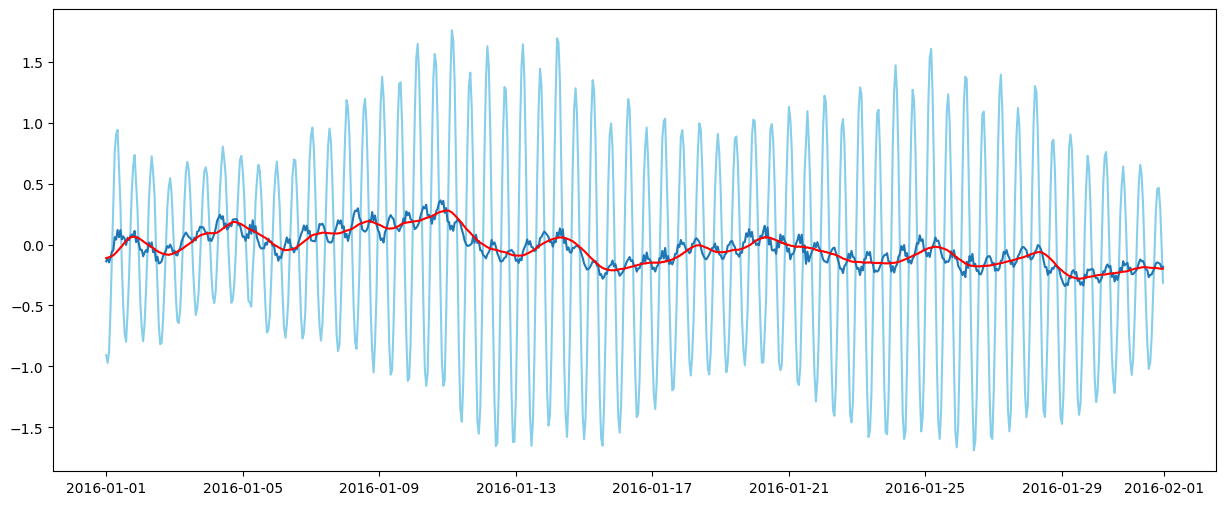

In [77]:
year_to_filter = 2016
month_to_filter = 1
twl_ssr_f = twl_ssr[(twl_ssr.index.year == year_to_filter) & (twl_ssr.index.month == month_to_filter)]
fig, ax = plt.subplots(figsize=(15,6))
ax.plot(twl_ssr_f.index, twl_ssr_f['waterlevel'], label='Storm Surge + Astronomical tide - Sea Level Rise',color='skyblue')
ax.plot(twl_ssr_f.index, twl_ssr_f['surge'])
ax.plot(twl_ssr_f.index, media_movil[(twl_ssr.index.year == year_to_filter) & (twl_ssr.index.month == month_to_filter)],color='red')

In [79]:
twl_ssr['surge_rolling_mean'] = media_movil.values 
twl_ssr

,waterlevel,surge,surge_rolling_mean
time,,,
1979-01-01 00:00:00,-0.026,0.808,NaN
1979-01-01 01:00:00,0.049,0.072,NaN
1979-01-01 02:00:00,0.023,-0.794,NaN
1979-01-01 03:00:00,0.043999,-1.439,NaN
1979-01-01 04:00:00,0.066999,-1.743,NaN
...,...,...,...
2018-12-31 19:00:00,-0.451775,-0.132,-0.174583
2018-12-31 20:00:00,0.069225,-0.080,-0.172250
2018-12-31 21:00:00,0.397224,-0.180,-0.173750


In [80]:
# Calcular la diferencia entre tiempos consecutivos
time_diffs = twl_ssr.index.to_series().diff()

# Filtrar donde hay un salto mayor al mínimo esperado
saltos = time_diffs[time_diffs > time_diffs.min()]

# Mostrar las fechas donde hay saltos
print("Fechas con saltos en la serie:")
print(saltos.index)

Fechas con saltos en la serie:
DatetimeIndex(['1979-02-19 14:00:00', '1979-03-31 10:00:00',
               '1979-06-17 16:00:00', '1979-06-26 22:00:00',
               '1979-08-15 02:00:00', '1979-08-20 20:00:00',
               '1979-11-21 21:00:00', '1980-06-16 23:00:00',
               '1980-09-02 15:00:00', '1980-10-04 19:00:00',
               ...
               '2017-06-13 11:00:00', '2017-07-27 02:00:00',
               '2017-12-18 11:00:00', '2018-03-04 10:00:00',
               '2018-05-22 03:00:00', '2018-06-02 11:00:00',
               '2018-07-03 00:00:00', '2018-09-08 07:00:00',
               '2018-10-05 20:00:00', '2018-12-01 04:00:00'],
              dtype='datetime64[ns]', name='time', length=233, freq=None)


In [81]:
len(saltos)

233

In [82]:
# Crear un nuevo índice con frecuencia regular
time_range = pd.date_range(start=twl_ssr.index.min(), end=twl_ssr.index.max(), freq="H")  # Ajusta la frecuencia según tus datos

# Reindexar para agregar las fechas faltantes
twl_ssr = twl_ssr.reindex(time_range)

# Interpolar valores faltantes
twl_ssr = twl_ssr.interpolate(method="time")
twl_ssr

/tmp/ipykernel_2405429/2429385712.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_range = pd.date_range(start=twl_ssr.index.min(), end=twl_ssr.index.max(), freq="H")  # Ajusta la frecuencia según tus datos
/tmp/ipykernel_2405429/2429385712.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  twl_ssr = twl_ssr.interpolate(method="time")


,waterlevel,surge,surge_rolling_mean
1979-01-01 00:00:00,-0.026,0.808,NaN
1979-01-01 01:00:00,0.049,0.072,NaN
1979-01-01 02:00:00,0.023,-0.794,NaN
1979-01-01 03:00:00,0.043999,-1.439,NaN
1979-01-01 04:00:00,0.066999,-1.743,NaN
...,...,...,...
2018-12-31 19:00:00,-0.451775,-0.132,-0.174583
2018-12-31 20:00:00,0.069225,-0.080,-0.172250
2018-12-31 21:00:00,0.397224,-0.180,-0.173750
2018-12-31 22:00:00,0.724224,-0.123,-0.168250


In [83]:
# Calcular la diferencia entre tiempos consecutivos
time_diffs = twl_ssr.index.to_series().diff()

# Filtrar donde hay un salto mayor al mínimo esperado
saltos = time_diffs[time_diffs > time_diffs.min()]

# Mostrar las fechas donde hay saltos
print("Fechas con saltos en la serie:")
print(saltos.index)


Fechas con saltos en la serie:
DatetimeIndex([], dtype='datetime64[ns]', freq='h')


In [84]:
twl_ssr

,waterlevel,surge,surge_rolling_mean
1979-01-01 00:00:00,-0.026,0.808,NaN
1979-01-01 01:00:00,0.049,0.072,NaN
1979-01-01 02:00:00,0.023,-0.794,NaN
1979-01-01 03:00:00,0.043999,-1.439,NaN
1979-01-01 04:00:00,0.066999,-1.743,NaN
...,...,...,...
2018-12-31 19:00:00,-0.451775,-0.132,-0.174583
2018-12-31 20:00:00,0.069225,-0.080,-0.172250
2018-12-31 21:00:00,0.397224,-0.180,-0.173750
2018-12-31 22:00:00,0.724224,-0.123,-0.168250


In [85]:
ds_twl_ssr = twl_ssr.to_xarray()
ds_twl_ssr

<xarray.Dataset> Size: 11MB
Dimensions:             (index: 350640)
Coordinates:
  * index               (index) datetime64[ns] 3MB 1979-01-01 ... 2018-12-31T...
Data variables:
    waterlevel          (index) object 3MB -0.026 0.049 0.023 ... 0.7242 0.6722
    surge               (index) float64 3MB 0.808 0.072 -0.794 ... -0.123 -0.221
    surge_rolling_mean  (index) float64 3MB nan nan nan ... -0.1682 -0.1679

In [86]:
ds_twl_ssr = ds_twl_ssr.rename_dims({"index": "time"})
ds_twl_ssr = ds_twl_ssr.rename({"index": "time"})

/tmp/ipykernel_2405429/1057451519.py:2: UserWarning: rename 'index' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds_twl_ssr = ds_twl_ssr.rename({"index": "time"})


In [87]:
ds_twl_ssr

<xarray.Dataset> Size: 11MB
Dimensions:             (time: 350640)
Coordinates:
  * time                (time) datetime64[ns] 3MB 1979-01-01 ... 2018-12-31T2...
Data variables:
    waterlevel          (time) object 3MB -0.026 0.049 0.023 ... 0.7242 0.6722
    surge               (time) float64 3MB 0.808 0.072 -0.794 ... -0.123 -0.221
    surge_rolling_mean  (time) float64 3MB nan nan nan ... -0.1682 -0.1679

In [88]:
ds_twl_ssr = ds_twl_ssr.resample(time="1D").mean()


In [89]:
ds_twl_ssr.to_netcdf('ds_ss_Oporto_codec_rolling_mean.nc')